In [8]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


#### The idea and pieces are explained in version 9.0. 
##### In this version the inconsities caused during simulation of noise is removed 
#### So in my opinion this way is more robust for MFQEC

In [9]:
def add_noise_to_stim_circuit(
    circuit: stim.Circuit,
    data_qubits: list,
    p_clifford_depol: float = 0.0,
    p_data_idle: float = 0.0,
    p_measure_flip: float = 0.0,
    p_reset_flip: float = 0.0,
    biased_noise_tuple: tuple = (0.0, 0.0, 0.0)
) -> stim.Circuit:
    noisy_circuit = stim.Circuit()
    
    # Gate Sets
    clifford_1q = {"H", "S", "S_DAG", "X", "Y", "Z", "SQRT_X", "SQRT_Y", "SQRT_Z", "I"}
    clifford_2q = {"CNOT", "CX", "CY", "CZ", "SWAP"}
    
    px, py, pz = biased_noise_tuple
    has_biased_noise = (px > 0 or py > 0 or pz > 0)
    
    for instruction in circuit:
        name = instruction.name
        targets = instruction.targets_copy()
        
        # --- 1. RESET NOISE ---
        if name == "R":
            noisy_circuit.append(instruction)
            if p_reset_flip > 0:
                for t in targets:
                    if np.random.random() < p_reset_flip:
                        # Use X_ERROR with p=1 so Stim knows it's a fault
                        noisy_circuit.append("X_ERROR", [t.value], 1)

        # --- 2. MEASUREMENT NOISE ---
        elif name == "M" or name == "MR":
            if p_measure_flip > 0:
                for t in targets:
                    if np.random.random() < p_measure_flip:
                        noisy_circuit.append("X_ERROR", [t.value], 1)
            noisy_circuit.append(instruction)
            if name == "MR" and p_reset_flip > 0:
                for t in targets:
                    if np.random.random() < p_reset_flip:
                        noisy_circuit.append("X_ERROR", [t.value], 1)

        # --- 3. IDLE NOISE (TICK) ---
        elif name == "TICK":
            noisy_circuit.append(instruction)
            if p_data_idle > 0:
                for q in data_qubits:
                    if np.random.random() < p_data_idle:
                        outcome = np.random.randint(3)
                        # Use _ERROR channels with p=1
                        gate = ["X_ERROR", "Y_ERROR", "Z_ERROR"][outcome]
                        noisy_circuit.append(gate, [q], 1)

# --- 4. GATE NOISE ---
        elif name in clifford_1q or name in clifford_2q:
            noisy_circuit.append(instruction) # Apply clean gate first
            
            raw_targets = [t.value for t in targets if not t.is_combiner]
            
            # A. Depolarization
            if p_clifford_depol > 0:
                
                # === NEW: Handle 2-Qubit Gates (Correlated) ===
                if name in clifford_2q:
                    # Stim stores targets as flat list [c1, t1, c2, t2...]
                    # We iterate in steps of 2
                    for i in range(0, len(raw_targets), 2):
                        q1 = raw_targets[i]
                        q2 = raw_targets[i+1]
                        
                        # 1. Roll dice ONCE for the pair
                        if np.random.random() < p_clifford_depol:
                            # 2. Pick a random 2-qubit Pauli (IX, IY... ZZ)
                            # We need any pair (p1, p2) except (I, I)
                            p1, p2 = 0, 0
                            while p1 == 0 and p2 == 0:
                                p1 = np.random.randint(4) # 0=I, 1=X, 2=Y, 3=Z
                                p2 = np.random.randint(4)
                            
                            # 3. Apply the Static Errors (p=1)
                            # Apply error to Control (q1)
                            if p1 > 0:
                                gate = ["X_ERROR", "Y_ERROR", "Z_ERROR"][p1-1]
                                noisy_circuit.append(gate, [q1], 1)
                            
                            # Apply error to Target (q2)
                            if p2 > 0:
                                gate = ["X_ERROR", "Y_ERROR", "Z_ERROR"][p2-1]
                                noisy_circuit.append(gate, [q2], 1)

                # === Handle 1-Qubit Gates (Independent) ===
                else:
                    for q in raw_targets:
                        if np.random.random() < p_clifford_depol:
                            outcome = np.random.randint(3)
                            gate = ["X_ERROR", "Y_ERROR", "Z_ERROR"][outcome]
                            noisy_circuit.append(gate, [q], 1)

            # B. Biased Noise
            if has_biased_noise:
                for q in raw_targets:
                    # Pauli Channel 1 with explicit probs is already a noise channel
                    # So this is fine as-is
                    noisy_circuit.append("PAULI_CHANNEL_1", [q], [px, py, pz])

        else:
            noisy_circuit.append(instruction)
            
    return noisy_circuit

### Simulating measurement based repetition code
##### Decoding is done using pymatching, standard stuffs except the new noise models and encoder part. 
##### This would be later compared with MBQEC

In [10]:
# ==========================================
# 2. MAIN SIMULATION LOOP
# ==========================================

drange = [3, 5, 7]           # Distances
prange = np.linspace(0.001, 0.1, 4) # Physical error rates
num_shots = 2000             # Shots per point

results = {}

print("Starting Simulation...")

for d in drange:
    log_error_rates = []
    
    # Generate Clean Circuit (Template)
    # FIX: Added ":memory" to specify the exact task type
    clean_circuit = stim.Circuit.generated(
        "repetition_code:memory",
        rounds=d,
        distance=d,
        before_round_data_depolarization=0,
        before_measure_flip_probability=0,
        after_clifford_depolarization=0,
        after_reset_flip_probability=0
    ).flattened()
    
    # Identify Data Qubits (Even indices: 0, 2, 4...)
    data_qubits_indices = [q for q in range(0, 2*d - 1, 2)]
    
    print(f"Simulating d={d}...")
    
    for p in tqdm(prange, leave=False):
        
        # 1. Configure Pymatching Model
        # We create a dummy circuit with simple noise just to define the graph weights
        model_circuit = stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d,
            distance=d,
            after_clifford_depolarization=p,
            before_measure_flip_probability=p,
            after_reset_flip_probability=p
        )
        dem = model_circuit.detector_error_model(decompose_errors=True)
        matcher = pymatching.Matching.from_detector_error_model(dem)
        
        fails = 0
        
        # 2. Run Shots
        for _ in range(num_shots):
            # A. Create Fresh Noisy Circuit (Static Noise per Shot)
            noisy_shot = add_noise_to_stim_circuit(
                clean_circuit,
                data_qubits=data_qubits_indices,
                p_clifford_depol=p, 
                p_data_idle=0.0,
                p_measure_flip=p,
                p_reset_flip=p,
                biased_noise_tuple=(0.0, 0.0, 0.0)
            )
            
            # B. Sample
            sampler = noisy_shot.compile_detector_sampler()
            detection_events, actual_observables = sampler.sample(shots=1, separate_observables=True)
            
            # C. Decode
            predicted_observables = matcher.decode_batch(detection_events)
            
            # D. Count Errors
            if predicted_observables[0][0] != actual_observables[0][0]:
                fails += 1
        
        log_error_rates.append(fails / num_shots)
    
    results[d] = log_error_rates


Starting Simulation...
Simulating d=3...


Simulating d=5...


Simulating d=7...


### Plotting the threshold behaviour for MBQEC repetition code

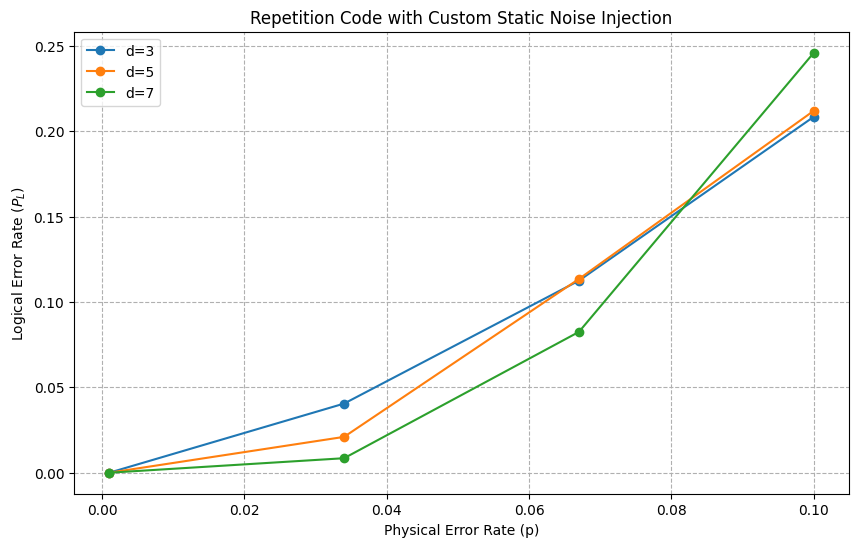

In [12]:
# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))
for d, rates in results.items():
    plt.plot(prange, rates, 'o-', label=f"d={d}")

plt.xlabel("Physical Error Rate (p)")
plt.ylabel("Logical Error Rate ($P_L$)")
plt.title("Repetition Code with Custom Static Noise Injection")
#plt.yscale("log")
plt.grid(True, which="both", linestyle="--")
plt.legend()
plt.show()

### Need for measurement and classical logic in MFQEC simulations

###### Since the aim is to perform simulations using stim, one major compromise one has to do is one cannot use toffoli's which are essential for MFQEC. This is because toffolis are not **Clifford**. 

###### The work around is that instead if just reset , do measure reset and mimic what a toffoli would do using a classical **lookup table**. 
###### On hindsight I believe this assumption is not all that bad , as long as one could mimic the noises that a Toffoli is expected to generate. 

###### Below are those lookup tables that will be used upto distance 9 code. 


###### Importantly measurment noises or idling noise for lookup time are never added in this circuit, hence the step of measurement and classical lookup table is not affecting any assumptions of MFQEC simulations.  


In [13]:
def corrector(circuit , d , j):
    sampler = circuit.compile_sampler()
    s = sampler.sample(shots=1)[0]
    if int(s[0 + 6*j]) == 1 and int(s[1 + 6*j]) == 0:
        circuit.append("X" , [0])
    elif int(s[2 + 6*j]) == 1 and int(s[3+6*j]) == 1:
        circuit.append("X" , [1])
    elif int(s[4+6*j]) == 0 and int(s[5+6*j]) == 1:
        circuit.append("X" , [2])
    return circuit


def corrector4(circuit , d , j):
    sampler = circuit.compile_sampler()
    # Capture the sample ONCE for consistency (Critical for correctness)
    s = sampler.sample(shots=1)[0]
    if int(s[0 + 12*j]) == 1 and int(s[1 + 12*j]) == 0 and int(s[2 + 12*j]) == 0:
        circuit.append("X" , [0])
    elif int(s[3 + 12*j]) == 1 and int(s[4 + 12*j]) == 1 and int(s[5 + 12*j]) == 0:
        circuit.append("X" , [1])
    elif int(s[6 + 12*j]) == 0 and int(s[7 + 12*j]) == 1 and int(s[8 + 12*j]) == 1:
        circuit.append("X" , [2])
    elif int(s[9 + 12*j]) == 0 and int(s[10 + 12*j]) == 0 and int(s[11 + 12*j]) == 1:
        circuit.append("X" , [3])
    return circuit

def corrector5(circuit, d, j):
    sampler = circuit.compile_sampler()
    
    # Capture the sample ONCE for consistency (Critical for correctness)
    s = sampler.sample(shots=1)[0]
    
    # Offset for the current round (20 bits per round for d=5)
    offset = 20 * j

    # Check Qubit 0 (Pattern 1 0 0 0 on bits 0-3)
    if (int(s[0 + offset]) == 1 and 
        int(s[1 + offset]) == 0 and 
        int(s[2 + offset]) == 0 and 
        int(s[3 + offset]) == 0):
        circuit.append("X", [0])

    # Check Qubit 1 (Pattern 1 1 0 0 on bits 4-7)
    elif (int(s[4 + offset]) == 1 and 
          int(s[5 + offset]) == 1 and 
          int(s[6 + offset]) == 0 and 
          int(s[7 + offset]) == 0):
        circuit.append("X", [1])

    # Check Qubit 2 (Pattern 0 1 1 0 on bits 8-11)
    elif (int(s[8 + offset]) == 0 and 
          int(s[9 + offset]) == 1 and 
          int(s[10 + offset]) == 1 and 
          int(s[11 + offset]) == 0):
        circuit.append("X", [2])

    # Check Qubit 3 (Pattern 0 0 1 1 on bits 12-15)
    elif (int(s[12 + offset]) == 0 and 
          int(s[13 + offset]) == 0 and 
          int(s[14 + offset]) == 1 and 
          int(s[15 + offset]) == 1):
        circuit.append("X", [3])

    # Check Qubit 4 (Pattern 0 0 0 1 on bits 16-19)
    elif (int(s[16 + offset]) == 0 and 
          int(s[17 + offset]) == 0 and 
          int(s[18 + offset]) == 0 and 
          int(s[19 + offset]) == 1):
        circuit.append("X", [4])

    return circuit


def corrector7(circuit, d, j):
    sampler = circuit.compile_sampler()
    s = sampler.sample(shots=1)[0]
    
    # 42 bits per round (7 reps * 6 ancillas)
    # Base offset for the current round 'j'
    base = 42 * j 
    
    # Q0: Check Rep 0 (Ancillas 0-5) -> Pattern 1 0 0 0 0 0
    if (int(s[base + 0]) == 1 and int(s[base + 1]) == 0):
        circuit.append("X", [0])

    # Q1: Check Rep 1 (Ancillas 0-5) -> Pattern 1 1 0 0 0 0
    elif (int(s[base + 6]) == 1 and int(s[base + 7]) == 1 and int(s[base + 8]) == 0):
        circuit.append("X", [1])

    # Q2: Check Rep 2 -> Pattern 0 1 1 0 0 0
    elif (int(s[base + 12]) == 0 and int(s[base + 13]) == 1 and 
          int(s[base + 14]) == 1 and int(s[base + 15]) == 0):
        circuit.append("X", [2])

    # Q3: Check Rep 3 -> Pattern 0 0 1 1 0 0
    elif (int(s[base + 20]) == 1 and int(s[base + 21]) == 1 and 
          int(s[base + 22]) == 0 and int(s[base + 23]) == 0):
        circuit.append("X", [3])

    # Q4: Check Rep 4 -> Pattern 0 0 0 1 1 0
    elif (int(s[base + 27]) == 1 and int(s[base + 28]) == 1 and 
          int(s[base + 29]) == 0 and int(s[base + 30]) == 0):
        circuit.append("X", [4])

    # Q5: Check Rep 5 -> Pattern 0 0 0 0 1 1
    elif (int(s[base + 34]) == 1 and int(s[base + 35]) == 1 and 
          int(s[base + 36]) == 0):
        circuit.append("X", [5])

    # Q6: Check Rep 6 -> Pattern 0 0 0 0 0 1
    elif (int(s[base + 40]) == 0 and int(s[base + 41]) == 1):
        circuit.append("X", [6])

    return circuit

def corrector9(circuit, d, j):
    sampler = circuit.compile_sampler()
    s = sampler.sample(shots=1)[0]
    
    # 72 bits per round (9 reps * 8 ancillas)
    base = 72 * j

    # Q0: Rep 0 -> 1 0 ...
    if (int(s[base + 0]) == 1 and int(s[base + 1]) == 0):
        circuit.append("X", [0])

    # Q1: Rep 1 -> 1 1 0 ...
    elif (int(s[base + 8]) == 1 and int(s[base + 9]) == 1 and int(s[base + 10]) == 0):
        circuit.append("X", [1])

    # Q2: Rep 2 -> 0 1 1 0 ...
    elif (int(s[base + 17]) == 1 and int(s[base + 18]) == 1 and 
          int(s[base + 19]) == 0 and int(s[base + 20]) == 0):
        circuit.append("X", [2])

    # Q3: Rep 3 -> 0 0 1 1 0 ...
    elif (int(s[base + 26]) == 1 and int(s[base + 27]) == 1 and 
          int(s[base + 28]) == 0 and int(s[base + 29]) == 0):
        circuit.append("X", [3])

    # Q4: Rep 4 -> 0 0 0 1 1 0 ...
    elif (int(s[base + 35]) == 1 and int(s[base + 36]) == 1 and 
          int(s[base + 37]) == 0 and int(s[base + 38]) == 0):
        circuit.append("X", [4])

    # Q5: Rep 5 -> 0 0 0 0 1 1 0 ...
    elif (int(s[base + 44]) == 1 and int(s[base + 45]) == 1 and 
          int(s[base + 46]) == 0 and int(s[base + 47]) == 0):
        circuit.append("X", [5])

    # Q6: Rep 6 -> 0 0 0 0 0 1 1 0
    elif (int(s[base + 53]) == 1 and int(s[base + 54]) == 1 and 
          int(s[base + 55]) == 0 and int(s[base + 56]) == 0):
        circuit.append("X", [6])

    # Q7: Rep 7 -> 0 0 0 0 0 0 1 1
    elif (int(s[base + 62]) == 1 and int(s[base + 63]) == 1 and 
          int(s[base + 64]) == 0):
        circuit.append("X", [7])

    # Q8: Rep 8 -> 0 0 0 0 0 0 0 1
    elif (int(s[base + 70]) == 0 and int(s[base + 71]) == 1):
        circuit.append("X", [8])

    return circuit

#### A function to generate MFQEC **clean** circuit for multiple rounds and distance. 

In [14]:
def encoder_mf_st(d): 
    data_qubits = d
    plus_qubits = d
    ancilla_qubits = d-1
    total_qubits = data_qubits + plus_qubits + ancilla_qubits

    circuit = st.Circuit()

    # --- 1. Initial Clean Reset (All Qubits) ---
    circuit.append("R", range(total_qubits))

    # --- 2. Manual Encoder ---
    # CNOT from Data 0 to Data 2, 4, 6... (Even indices)
    data_qubits_indices = [0]
    for i in range( 1,data_qubits):
        circuit.append("CNOT", [0, i])
        data_qubits_indices.append(i)
    circuit.append("H" , [data_qubits])
    
    # Plus state encoder
    for i in range(data_qubits+1, (data_qubits + plus_qubits)):
        circuit.append("CNOT", [data_qubits,i])
    return circuit , data_qubits_indices
def synd_extractor_mf_st(d):
    circuit = st.Circuit()
    data_qubits = d
    plus_qubits = d
    ancilla_qubits = d-1
    total_qubits = data_qubits + plus_qubits + ancilla_qubits
    for i in range(data_qubits):
        circuit.append("CNOT", [i,i+data_qubits])
    for i in range(ancilla_qubits):
        circuit.append("CNOT", [i+data_qubits,(i+data_qubits+plus_qubits)])
        circuit.append("CNOT", [i+data_qubits+1,(i+data_qubits+plus_qubits)])
    circuit.append("R" ,range(data_qubits , data_qubits+ancilla_qubits))
        # Reset and syndrome copying and repeat that for each data qubit
    for _ in range(data_qubits):
        #circuit.append("MR" ,range(data_qubits , data_qubits+ancilla_qubits))
        for i in range(ancilla_qubits):
            circuit.append("CNOT", [(i+data_qubits+plus_qubits),i+data_qubits])
        circuit.append("MR" ,range(data_qubits , data_qubits+ancilla_qubits))
    return circuit

def toffoli_mimicer_mf_st(circuit , d , j):
    data_qubits = d
    plus_qubits = d
    ancilla_qubits = d-1
    total_qubits = data_qubits + plus_qubits + ancilla_qubits
    if(data_qubits == 3):
        circuit = corrector(circuit , data_qubits , j)
    elif(data_qubits == 4):
        circuit = corrector4(circuit , data_qubits , j)
    elif(data_qubits == 5):
        circuit = corrector5(circuit , data_qubits , j)
    elif(data_qubits == 7):
        circuit = corrector7(circuit , data_qubits , j)
    elif(data_qubits == 9):
        circuit = corrector9(circuit , data_qubits , j)
    circuit.append("R",range(data_qubits,total_qubits))

    return circuit



##### As shown in the orginal paper for bitflip errors on just one qubit the code must be able to correct it. So below we shall do a sanity check where

##### 5 qubit MFQEC code is simulated with bitflip injected **intentionally** at q[1]. If the code works well it must apply a correction operator in

##### the first round and second round must be free of any error / corrections for that matter.   

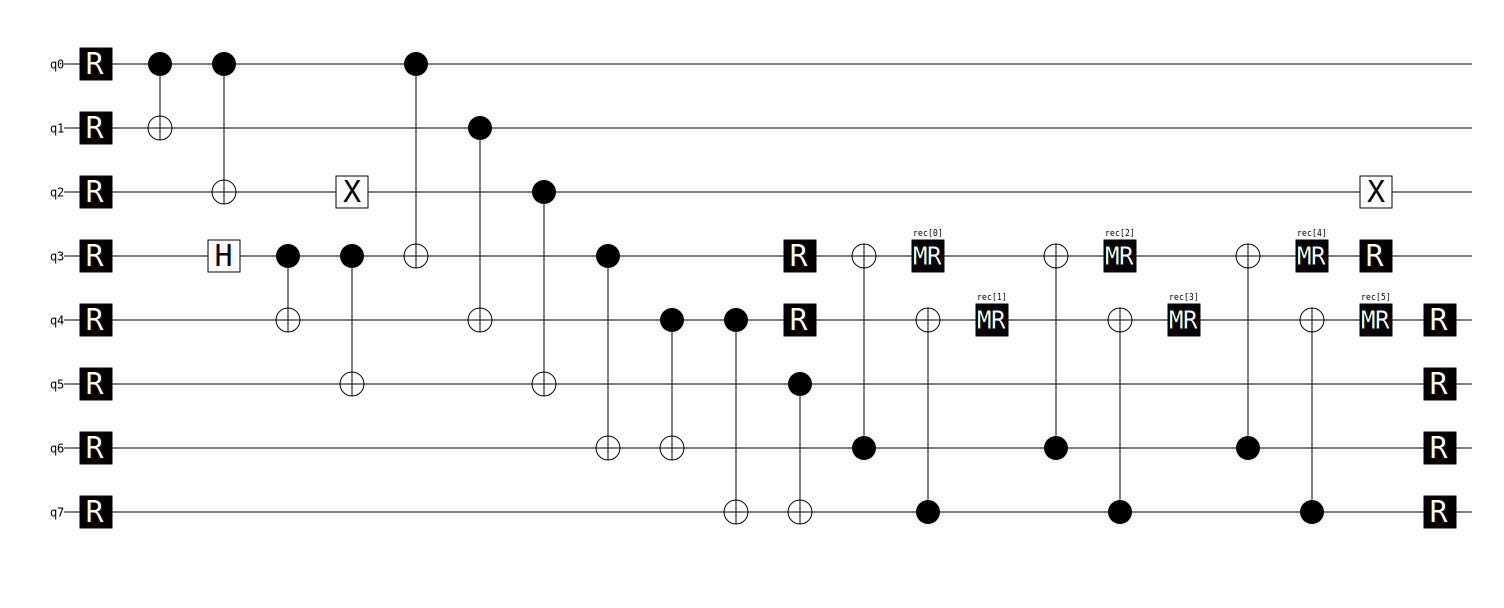

In [15]:
def generate_stim_rep_code_circuit_MF(d , r ):
    data_qubits = d
    plus_qubits = d
    ancilla_qubits = d-1
    total_qubits = data_qubits + plus_qubits + ancilla_qubits

    circuit = st.Circuit()

    # --- 1. Initial Clean Reset (All Qubits) ---
    circuit.append("R", range(total_qubits))

    # --- 2. Manual Encoder ---
    # CNOT from Data 0 to Data 2, 4, 6... (Even indices)
    data_qubits_indices = [0]
    for i in range( 1,data_qubits):
        circuit.append("CNOT", [0, i])
        data_qubits_indices.append(i)
    circuit.append("H" , [data_qubits])
    
    # Plus state encoder
    for i in range(data_qubits+1, (data_qubits + plus_qubits)):
        circuit.append("CNOT", [data_qubits,i])

     #Error injection
    circuit.append("X", [2])
    #circuit.append()
    #circuit.append("X", [1])
    #circuit.append("X", [1])
    #circuit.append("PAULI_CHANNEL_1", range(0 , int((d-1)/2)), [p, 0, 0])
    
    

    #Syndrome storing
    for j in range(r):
        #Error copier
        for i in range(data_qubits):
            circuit.append("CNOT", [i,i+data_qubits])
        for i in range(ancilla_qubits):
            circuit.append("CNOT", [i+data_qubits,(i+data_qubits+plus_qubits)])
            circuit.append("CNOT", [i+data_qubits+1,(i+data_qubits+plus_qubits)])
        circuit.append("R" ,range(data_qubits , data_qubits+ancilla_qubits))
        # Reset and syndrome copying and repeat that for each data qubit
        for _ in range(data_qubits):
            #circuit.append("MR" ,range(data_qubits , data_qubits+ancilla_qubits))
            for i in range(ancilla_qubits):
                circuit.append("CNOT", [(i+data_qubits+plus_qubits),i+data_qubits])
            circuit.append("MR" ,range(data_qubits , data_qubits+ancilla_qubits))
        if(data_qubits == 3):
            circuit = corrector(circuit , data_qubits , j)
        elif(data_qubits == 4):
            circuit = corrector4(circuit , data_qubits , j)
        elif(data_qubits == 5):
            circuit = corrector5(circuit , data_qubits , j)
        elif(data_qubits == 7):
            circuit = corrector7(circuit , data_qubits , j)
        elif(data_qubits == 9):
            circuit = corrector9(circuit , data_qubits , j)
        
        
        circuit.append("R",range(data_qubits,total_qubits))
    return circuit ,data_qubits_indices


circuit , indices = generate_stim_rep_code_circuit_MF(3 , 2)
circuit.append("M" ,indices )

sampler = circuit.compile_sampler()
(sampler.sample(shots = 1)[0][[-1,-2,-3]])
check , indices = generate_stim_rep_code_circuit_MF(3 , 1 )
check.diagram("timeline-svg")

#listt = list(np.array(indices) - len(indices))
#sampler.sample(shots = 1)[0][listt]

### Now we are in a position to do threshold theorem plots. 

### Two things to verify 

##### 1) In repetition code under MFQEC for some model and strength of noise does increasing distance supress logical error rate ?

##### 2) Does multiple rounds really help to supress noise ? or does it add more noise 




In [39]:
drange = range(3 , 8 , 2)
prange = np.linspace(0.001 , 0.1 , 4)

num_shots = int(1e3)


log_error_list = []
for d in drange:
    rounds = 1
    clean_circuit , data_qubits_indices = encoder_mf_st(d) 
    clean_se_circuit = synd_extractor_mf_st(d)
    log_error_perc = []
    for p in tqdm(prange):
    #p = 0.2
    
        num_errors = 0
        for i in range(num_shots):
            noisy_circuit = add_noise_to_stim_circuit(clean_circuit.flattened(),\
                                                      data_qubits=data_qubits_indices,\
                                                      p_clifford_depol=p,         # Depol after gates 
                                                      p_data_idle=0,             #  Idle noise at TICKs
                                                      p_measure_flip=0,           #  Readout error
                                                      p_reset_flip=0,             # Reset error
                                                      biased_noise_tuple=(0.00, 0.0, 0.0)) # 
            noisy_se_circuit = add_noise_to_stim_circuit(clean_se_circuit.flattened(),\
                                                  data_qubits=data_qubits_indices,\
                                                  p_clifford_depol= p,         # Depol after gates 
                                                  p_data_idle=0,             #  Idle noise at TICKs
                                                  p_measure_flip=0,           #  Readout error
                                                  p_reset_flip=p,             # Reset error
                                                  biased_noise_tuple=(0, 0.0, 0.0)) #  Bias after every gate
            for r in range(rounds):
                noisy_circuit.append(noisy_se_circuit)
                noisy_circuit = toffoli_mimicer_mf_st(noisy_circuit , d , r)
            
            noisy_circuit.append("X_ERROR" , data_qubits_indices , p)
            noisy_circuit.append("M" ,data_qubits_indices )
            sampler = noisy_circuit.compile_sampler()
            listt = list(np.array(indices) - len(indices))
            syndrome = sampler.sample(shots = 1)[0][listt]
               
            num_errors += (np.sum(syndrome) > (len(syndrome) / 2))
        log_error_perc.append(num_errors/num_shots)
    log_error_list.append(log_error_perc)


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.78s/it]


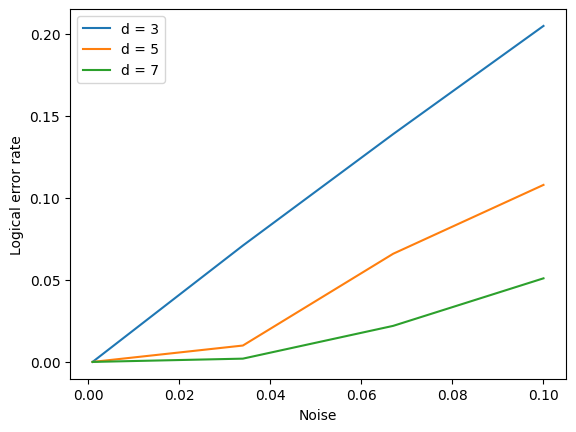

In [40]:
plt.xlabel("Noise")
plt.ylabel("Logical error rate")
plt.plot(prange , log_error_list[0] , label = f"d = {drange[0]}" )
plt.plot(prange , log_error_list[1], label = f"d = {drange[1]}" )

plt.plot(prange , log_error_list[2] , label = f"d = {drange[2]}")
#plt.plot(prange , log_error_list[3] , label = f"d = {drange[3]}")
plt.legend()
plt.show()

In [41]:
drange = range(3 , 8 , 2)
prange = np.linspace(0.001 , 0.1 , 4)
rrange = range(3 , 8 , 2)
num_shots = int(1e3)


log_error_list = []
for d in drange:
    rounds = 2
    clean_circuit , data_qubits_indices = encoder_mf_st(d) 
    clean_se_circuit = synd_extractor_mf_st(d)
    log_error_perc = []
    for p in tqdm(prange):
    #p = 0.2
    
        num_errors = 0
        for i in range(num_shots):
            noisy_circuit = add_noise_to_stim_circuit(clean_circuit.flattened(),\
                                                      data_qubits=data_qubits_indices,\
                                                      p_clifford_depol=p,         # Depol after gates 
                                                      p_data_idle=0,             #  Idle noise at TICKs
                                                      p_measure_flip=0,           #  Readout error
                                                      p_reset_flip=0,             # Reset error
                                                      biased_noise_tuple=(0.00, 0.0, 0.0)) # 
            noisy_se_circuit = add_noise_to_stim_circuit(clean_se_circuit.flattened(),\
                                                  data_qubits=data_qubits_indices,\
                                                  p_clifford_depol= p,         # Depol after gates 
                                                  p_data_idle=0,             #  Idle noise at TICKs
                                                  p_measure_flip=0,           #  Readout error
                                                  p_reset_flip=p,             # Reset error
                                                  biased_noise_tuple=(0, 0.0, 0.0)) #  Bias after every gate
            for r in range(rounds):
                noisy_circuit.append(noisy_se_circuit)
                noisy_circuit = toffoli_mimicer_mf_st(noisy_circuit , d , r)
            
            noisy_circuit.append("X_ERROR" , data_qubits_indices , p)
            noisy_circuit.append("M" ,data_qubits_indices )
            sampler = noisy_circuit.compile_sampler()
            listt = list(np.array(indices) - len(indices))
            syndrome = sampler.sample(shots = 1)[0][listt]
               
            num_errors += (np.sum(syndrome) > (len(syndrome) / 2))
        log_error_perc.append(num_errors/num_shots)
    log_error_list.append(log_error_perc)


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:13<00:00,  3.39s/it]


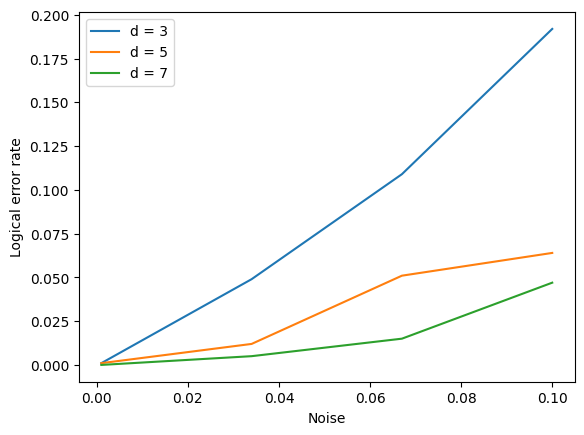

In [42]:
plt.xlabel("Noise")
plt.ylabel("Logical error rate")
plt.plot(prange , log_error_list[0] , label = f"d = {drange[0]}" )
plt.plot(prange , log_error_list[1], label = f"d = {drange[1]}" )

plt.plot(prange , log_error_list[2] , label = f"d = {drange[2]}")
#plt.plot(prange , log_error_list[3] , label = f"d = {drange[3]}")
plt.legend()
plt.show()

# The Threshold theorem plot

In [61]:
drange = range(3 , 10 , 2)
prange = np.linspace(0.001 , 0.02 , 4)
#rrange = range(3 , 8 , 2)
num_shots = int(1e4)


log_error_list = []
for d in drange:
    rounds = d
    clean_circuit , data_qubits_indices = encoder_mf_st(d) 
    clean_se_circuit = synd_extractor_mf_st(d)
    log_error_perc = []
    for p in tqdm(prange):
    #p = 0.2
    
        num_errors = 0
        for i in range(num_shots):
            noisy_circuit = add_noise_to_stim_circuit(clean_circuit.flattened(),\
                                                      data_qubits=data_qubits_indices,\
                                                      p_clifford_depol=p,         # Depol after gates 
                                                      p_data_idle=0,             #  Idle noise at TICKs
                                                      p_measure_flip=0,           #  Readout error
                                                      p_reset_flip=0,             # Reset error
                                                      biased_noise_tuple=(0.00, 0.0, 0.0)) # 
            noisy_se_circuit = add_noise_to_stim_circuit(clean_se_circuit.flattened(),\
                                                  data_qubits=data_qubits_indices,\
                                                  p_clifford_depol= p,         # Depol after gates 
                                                  p_data_idle=0,             #  Idle noise at TICKs
                                                  p_measure_flip=0,           #  Readout error
                                                  p_reset_flip=p,             # Reset error
                                                  biased_noise_tuple=(0, 0.0, 0.0)) #  Bias after every gate
            for r in range(rounds):
                noisy_circuit.append(noisy_se_circuit)
                noisy_circuit = toffoli_mimicer_mf_st(noisy_circuit , d , r)
            
            noisy_circuit.append("X_ERROR" , data_qubits_indices , rounds*p) # error by toffoli would accumelate for each round
            noisy_circuit.append("M" ,data_qubits_indices )
            sampler = noisy_circuit.compile_sampler()
            listt = list(np.array(indices) - len(indices))
            syndrome = sampler.sample(shots = 1)[0][listt]
               
            num_errors += (np.sum(syndrome) > (len(syndrome) / 2))
        log_error_perc.append(num_errors/num_shots)
    log_error_list.append(log_error_perc)


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [05:10<00:00, 77.70s/it]


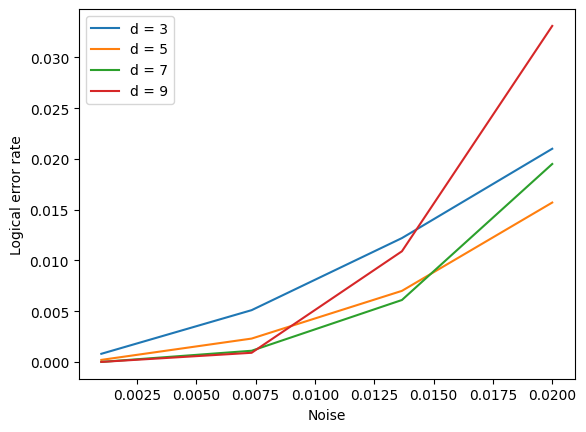

In [62]:
plt.xlabel("Noise")
plt.ylabel("Logical error rate")
plt.plot(prange , log_error_list[0] , label = f"d = {drange[0]}" )
plt.plot(prange , log_error_list[1], label = f"d = {drange[1]}" )

plt.plot(prange , log_error_list[2] , label = f"d = {drange[2]}")
plt.plot(prange , log_error_list[3] , label = f"d = {drange[3]}")
plt.legend()
plt.show()

### This simulation seems to work . 
#### Inorder to meaninfully compare both approaches I beleive a more intricate way of noise types are needed. 

#### The rather intuitive observation is that MFQEC would superseed traditional approach , only when toffoli is very very good. 